In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

In [5]:
results = {
    "Sentence Onset": {
        "Linear (raw)": (0.72, 0.02),
        "Linear (spectrogram)": (0.86, 0.015),
        "Linear (laplacian+spec)": (0.90, 0.01),
        "BrainBERT (frozen)": (0.71, 0.03),
        "BrainBERT (Wang 2023)": (0.74, 0.025),
        "PopulationTransformer": (0.77, 0.03),
    },
    "Speech": {
        "Linear (raw)": (0.61, 0.02),
        "Linear (spectrogram)": (0.85, 0.02),
        "Linear (laplacian+spec)": (0.89, 0.015),
        "BrainBERT (frozen)": (0.60, 0.02),
        "BrainBERT (Wang 2023)": (0.63, 0.02),
        "PopulationTransformer": (0.71, 0.03),
    },
    # add more tasks...
}


In [6]:
model_order = [
    "Linear (raw)",
    "Linear (spectrogram)",
    "Linear (laplacian+spec)",
    "BrainBERT (frozen)",
    "BrainBERT (Wang 2023)",
    "PopulationTransformer",
]

colors = {
    "Linear (raw)": "#4B3F72",
    "Linear (spectrogram)": "#365F8D",
    "Linear (laplacian+spec)": "#2A9D8F",
    "BrainBERT (frozen)": "#2A9D8F",
    "BrainBERT (Wang 2023)": "#52C569",
    "PopulationTransformer": "#A3E635",
}

model_order = ["linear", "vae", "dae", "hybrid", "gnn"]

colors = {
    "linear": "#4B3F72",
    "vae":    "#2A9D8F",
    "dae":    "#365F8D",
    "hybrid": "#52C569",
    "gnn":    "#A3E635",
}


In [24]:
def plot_model_comparison(results, ncols=5, chance=0.5):
    tasks = list(results.keys())
    n_tasks = len(tasks)
    nrows = int(np.ceil(n_tasks / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(3.2 * ncols, 3 * nrows),
        sharey=True
    )
    axes = axes.flatten()

    for ax, task in zip(axes, tasks):
        models = list(results[task].keys())
        means = [results[task][m][0] for m in models]
        errs = [results[task][m][1] for m in models]

        x = np.arange(len(models))
        ax.bar(
            x, means,
            yerr=errs,
            color=[colors[m] for m in models],
            capsize=3,
            width=0.75
        )

        ax.axhline(chance, linestyle="--", color="black", linewidth=1, alpha=0.7)
        pretty_task_name = {
        "mean_pixel_brightness": "Mean Frame Brightness",
        "delta_face_num_abs": "Δ_face_num_abs",
        "delta_mean_pixel_brightness_abs": "Δ_mean_frame_brightness_abs",
        "delta_delta_mean_pixel_brightness_abs": "ΔΔ_mean_frame_brightness_abs",
        "frame_brightness": "Mean Frame Brightness",  # optional
        }

        # inside plot_model_comparison loop:
        ax.set_title(pretty_task_name.get(task, task), fontsize=11)
        # ax.set_title(task, fontsize=11)
        ax.set_xticks([])
        ax.set_ylim(0.48, 0.95)

    # Remove empty subplots
    for ax in axes[len(tasks):]:
        ax.axis("off")

    # ADD after loop
    legend_elements = [
        Patch(facecolor=colors[m], label=m) for m in model_order
    ] + [
        Line2D([0], [0], color="black", linestyle="--", label="Chance")
    ]

    fig.legend(
        handles=legend_elements,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.03),  # move legend higher
        ncol=3,
        frameon=False
    )


    fig.text(0.04, 0.5, "AUROC", va="center", rotation="vertical", fontsize=12)
    # fig.tight_layout(rect=[0.05, 0, 1, 0.95])
    fig.tight_layout(rect=[0.05, 0, 1, 0.90])
    return fig


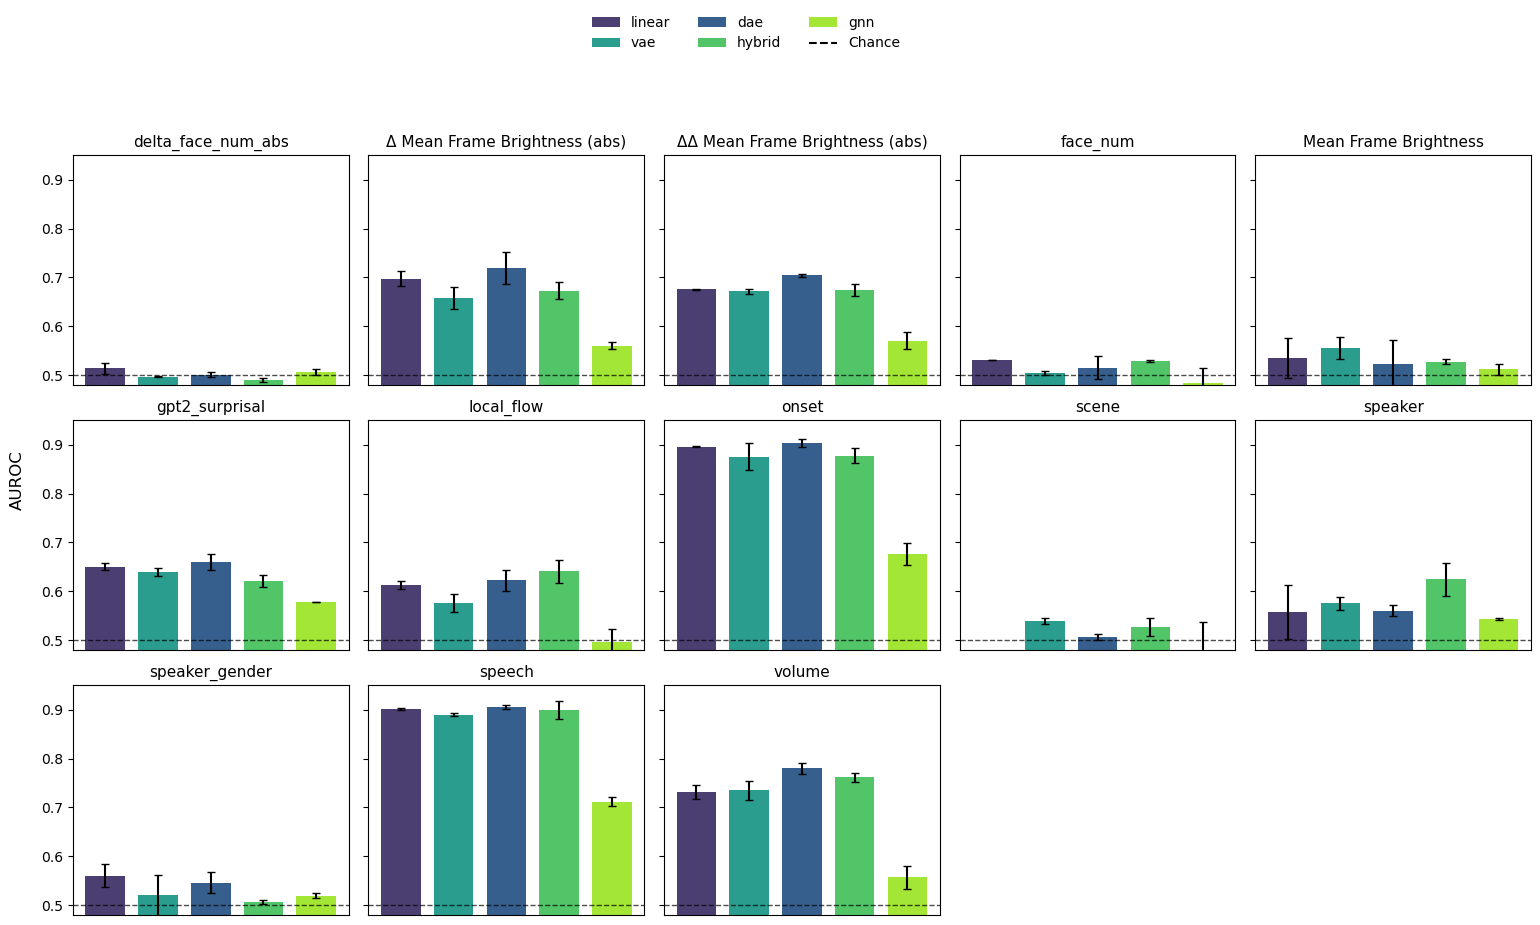

In [18]:
fig = plot_model_comparison(results, ncols=5)
plt.show()


In [34]:
import pandas as pd

# TASKS = ["speech", "volume", "local_flow", "frame_brightness", "face_num"]
SESSION_ID = "btbank3_0"  # change if needed

df = pd.read_csv("eval_results_export_new.csv")

# keep linear + your preprocess setting
df = df[df["model_dir"].str.startswith("linear_laplacian-stft_abs")]

# (optional) focus one subject/trial session
df = df[df["session_id"] == SESSION_ID]

# df = df[df["eval_name"].isin(TASKS)]

# choose metric: mean test ROC-AUC across folds
g = (
    df.groupby(["eval_name", "time_bin_start", "time_bin_end"], as_index=False)["test_roc_auc"]
      .mean()
      .rename(columns={"test_roc_auc": "mean_test_roc_auc"})
)

best = g.loc[g.groupby("eval_name")["mean_test_roc_auc"].idxmax()].sort_values("eval_name")
print(best.to_string(index=False))

                            eval_name  time_bin_start  time_bin_end  mean_test_roc_auc
delta_delta_mean_pixel_brightness_abs           0.125         0.375           0.675995
                   delta_face_num_abs           1.000         1.250           0.514232
      delta_mean_pixel_brightness_abs           0.125         0.375           0.697491
                             face_num           0.000         0.250           0.531357
                     frame_brightness           0.750         1.000           0.535406
                       gpt2_surprisal           0.125         0.375           0.650599
                           local_flow           0.500         0.750           0.613267
                                onset           0.125         0.375           0.896095
                                scene           0.125         0.375           0.420221
                              speaker           0.250         0.500           0.558324
                       speaker_gender      

In [11]:
import re
import numpy as np
import pandas as pd

SESSION_ID = "btbank3_0"
TASKS = [
    "delta_face_num_abs",
    "delta_mean_pixel_brightness_abs",
    "delta_delta_mean_pixel_brightness_abs",
    "face_num",
    "frame_brightness",
    "gpt2_surprisal",
    "local_flow",
    "onset",
    "scene",
    "speaker",
    "speaker_gender",
    "speech",
    "volume",
]
MODELS = ["linear", "vae", "dae", "hybrid", "gnn"]  # must match classifier_type used in folder names

df = pd.read_csv("eval_results_export_new.csv")
df = pd.read_csv("eval_results_export_new_with_delta_delta.csv")

# keep only this session + tasks
df = df[(df["session_id"] == SESSION_ID) & (df["eval_name"].isin(TASKS))]

# helper: classifier_type from model_dir like "dae_laplacian-stft_abs_..."
df["classifier_type"] = df["model_dir"].str.split("_", n=1).str[0]

# helper: run id from path "..._run2.json" (None -> 0)
def run_id(path):
    m = re.search(r"_run(\d+)\.json$", str(path))
    return int(m.group(1)) if m else 0

df["run_id"] = df["path"].map(run_id)

# OPTIONAL policy for multiple runs:
# Keep only the latest run per (task, model, bin, fold).
df = df.sort_values("run_id").groupby(
    ["eval_name", "classifier_type", "time_bin_start", "time_bin_end", "fold"],
    as_index=False
).tail(1)

# Step A: best bin per task from LINEAR
linear = df[df["classifier_type"] == "linear"]
best_bins = (
    linear.groupby(["eval_name","time_bin_start","time_bin_end"], as_index=False)["test_roc_auc"]
          .mean()
          .sort_values("test_roc_auc", ascending=False)
          .groupby("eval_name", as_index=False)
          .head(1)
          .set_index("eval_name")[["time_bin_start","time_bin_end"]]
)

# Step B/C: build results dict: results[task][model] = (mean, stderr)
results = {}
DEFAULT_BIN = (0.0, 1.0)  # (start, end)

for task in TASKS:
    if task in best_bins.index:
        t0 = float(best_bins.loc[task, "time_bin_start"])
        t1 = float(best_bins.loc[task, "time_bin_end"])
    else:
        t0, t1 = DEFAULT_BIN  # fallback if linear best-bin not available yet

    results[task] = {}
    for m in MODELS:
        sub = df[
            (df["eval_name"] == task) &
            (df["classifier_type"] == m) &
            (df["time_bin_start"] == t0) &
            (df["time_bin_end"] == t1)
        ]
        vals = sub["test_roc_auc"].to_numpy()
        mean = float(np.mean(vals)) if len(vals) else 0.0
        stderr = float(np.std(vals, ddof=1) / np.sqrt(len(vals))) if len(vals) > 1 else 0.0
        results[task][m] = (mean, stderr)

results

{'delta_face_num_abs': {'linear': (0.5142315287922009, 0.011269239208802182),
  'vae': (0.49676864884068417, 0.000922123653385981),
  'dae': (0.5012610628715923, 0.005121965873588097),
  'hybrid': (0.489845537757437, 0.004397066967597646),
  'gnn': (0.5062067019842638, 0.00570515030876778)},
 'delta_mean_pixel_brightness_abs': {'linear': (0.6974911967231958,
   0.015725734825449533),
  'vae': (0.6578372673792879, 0.02286762170464873),
  'dae': (0.7194131845396696, 0.03174404146160525),
  'hybrid': (0.6731692057720238, 0.018033003145146942),
  'gnn': (0.5606870996729465, 0.006916580462472455)},
 'delta_delta_mean_pixel_brightness_abs': {'linear': (0.6759950053812316,
   0.0014759202950795356),
  'vae': (0.6713556523828929, 0.004725557192564511),
  'dae': (0.7041707156515471, 0.003570943439599572),
  'hybrid': (0.6741011253565719, 0.012656343061345998),
  'gnn': (0.5702348672455408, 0.01734859408795958)},
 'face_num': {'linear': (0.5313574287117436, 0.0006478375808490754),
  'vae': (0.50

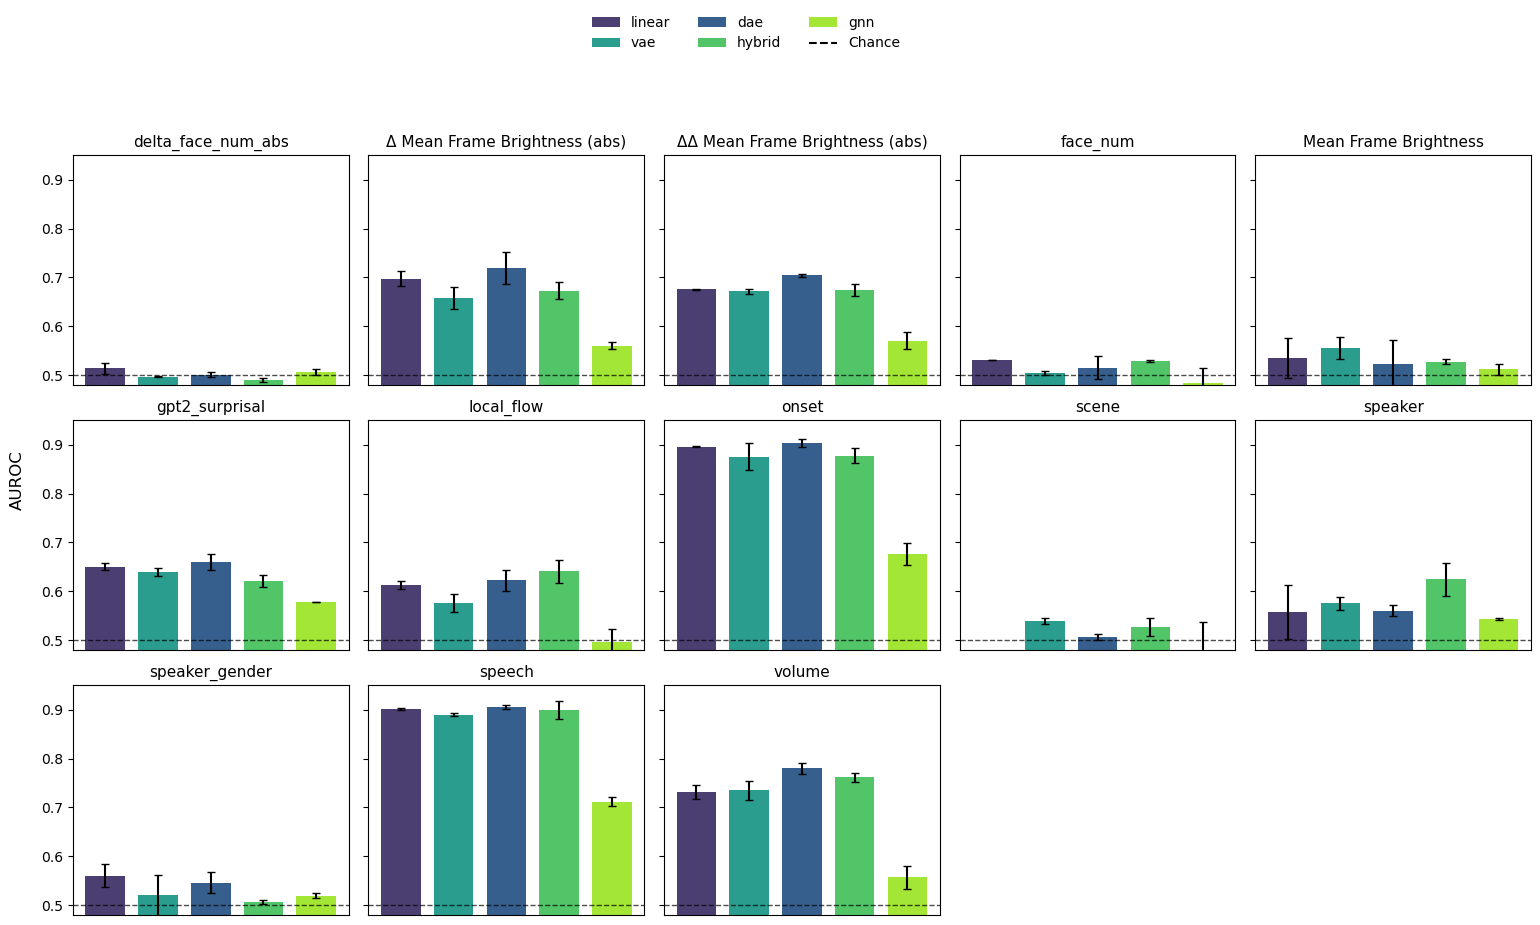

In [19]:
fig = plot_model_comparison(results, ncols=5)
plt.show()

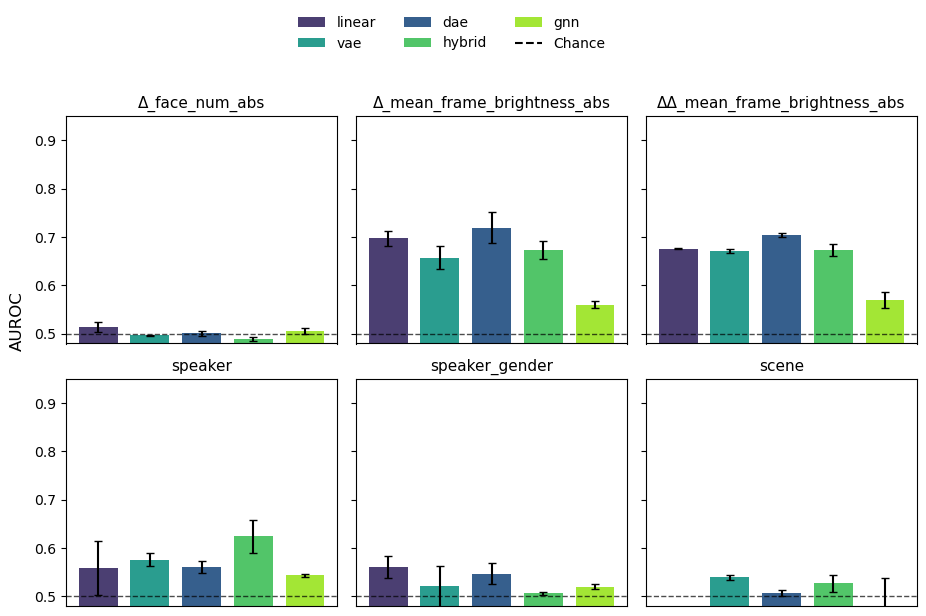

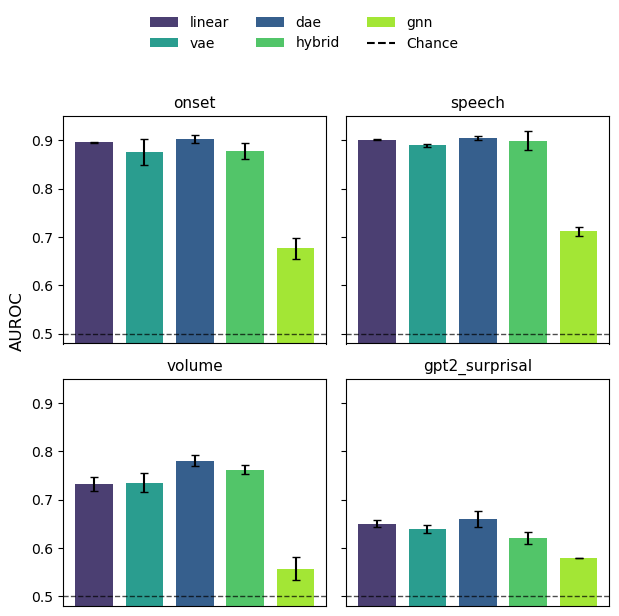

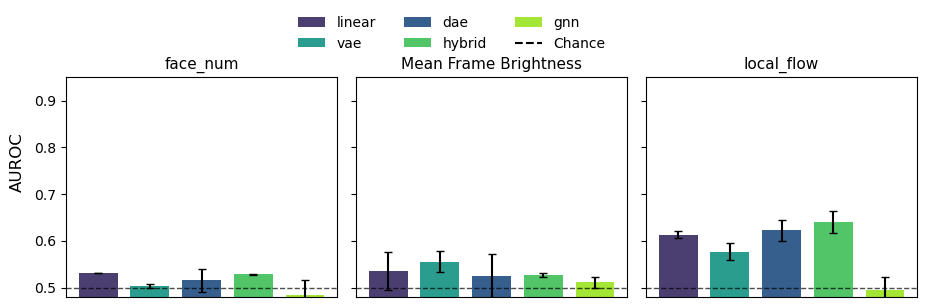

In [25]:
# 1) Define groups
new_features = [
    "delta_face_num_abs",
    "delta_mean_pixel_brightness_abs",
    "delta_delta_mean_pixel_brightness_abs",
    "speaker",
    "speaker_gender",
    "scene",
    # add any other new ones you have (e.g., gpt2_surprisal if you consider it "new")
]

top_benchmark = ["onset", "speech", "volume", "gpt2_surprisal"]

low_features = ["face_num", "frame_brightness", "local_flow"]

def subset_results(results, tasks):
    return {t: results[t] for t in tasks if t in results}

# 2) Plot separately
fig1 = plot_model_comparison(subset_results(results, new_features), ncols=3, chance=0.5)
fig2 = plot_model_comparison(subset_results(results, top_benchmark), ncols=2, chance=0.5)
fig3 = plot_model_comparison(subset_results(results, low_features), ncols=3, chance=0.5)

plt.show()